In [4]:
import polars as pl
from pathlib import Path

# Basis-Pfad definieren
processed_path = Path('..') / '02_data' / 'processed'

# Die einzelnen Marken-Dateien einlesen
df_amazon = pl.read_parquet(processed_path / 'ecommerce_amazon.parquet')
df_ebay = pl.read_parquet(processed_path / 'ecommerce_ebay.parquet')
df_aliexpress = pl.read_parquet(processed_path / 'ecommerce_aliexpress.parquet')
df_trendyol = pl.read_parquet(processed_path / 'ecommerce_tredyol.parquet')

# Den kombinierten Long-Format Datensatz (ideal für globale Features)
df = pl.read_parquet(processed_path / 'ecommerce_long_format.parquet')

print("Daten erfolgreich geladen!")

Daten erfolgreich geladen!


In [5]:
df

datetime,platform,sales
date,str,f64
2010-01-31,"""amazon""",162.50523
2010-02-28,"""amazon""",131.234988
2010-03-31,"""amazon""",142.409296
2010-04-30,"""amazon""",265.024017
2010-05-31,"""amazon""",154.458817
…,…,…
2019-08-31,"""trendyol""",82.833966
2019-09-30,"""trendyol""",79.782013
2019-10-31,"""trendyol""",77.831401


Die Daten haben im ersten Überblick gezeigt, dass keine fehlenden Werte vorliegen und die Bestellniveaus sich ziwschen den Marken unterscheiden. Es gibt allerdings keinerlei Infos darüber für welches Land/Region die Daten angezeigt werden.
Die Annahme wäre dabei folgende:
- USA: Starker Fokus auf Thanksgiving/Black Friday (Ende November).
- China (Aliexpress): Extrem hoher Peak im Novemver (Singles Days)
- Türkei (Trendyol): Eventuell Einflüsse durch den Ramadan (verschiebt sich jedes Jahr) oder nationale Feiertage.
- Europa: Oft starker Fokus auf Weihnachten - Dezember

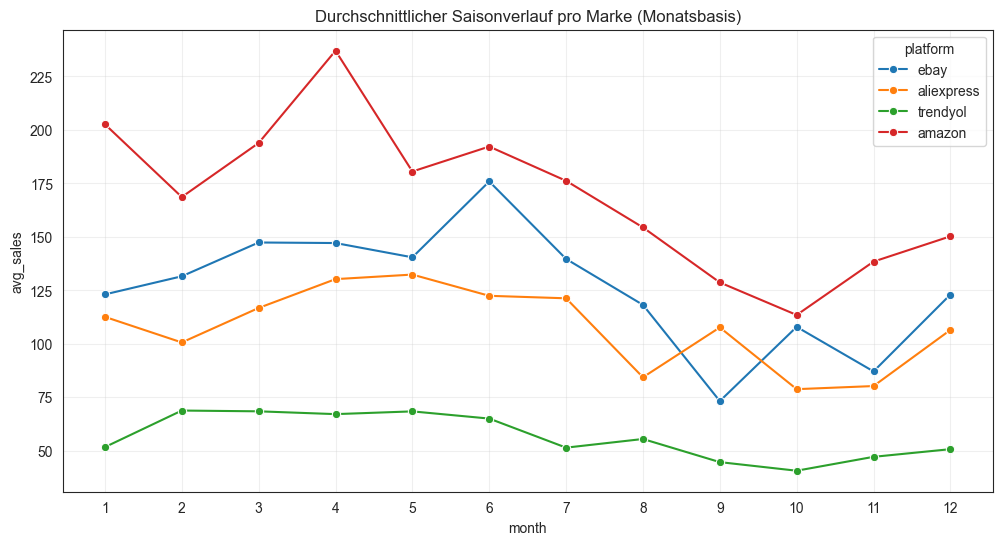

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_monthly_pattern = df.with_columns(
    pl.col("datetime").dt.month().alias("month")
).group_by(["platform", "month"]).agg(
    pl.col("sales").mean().alias("avg_sales")
).sort("month")

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_monthly_pattern.to_pandas(), x="month", y="avg_sales", hue="platform", marker="o")
plt.title("Durchschnittlicher Saisonverlauf pro Marke (Monatsbasis)")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.show()

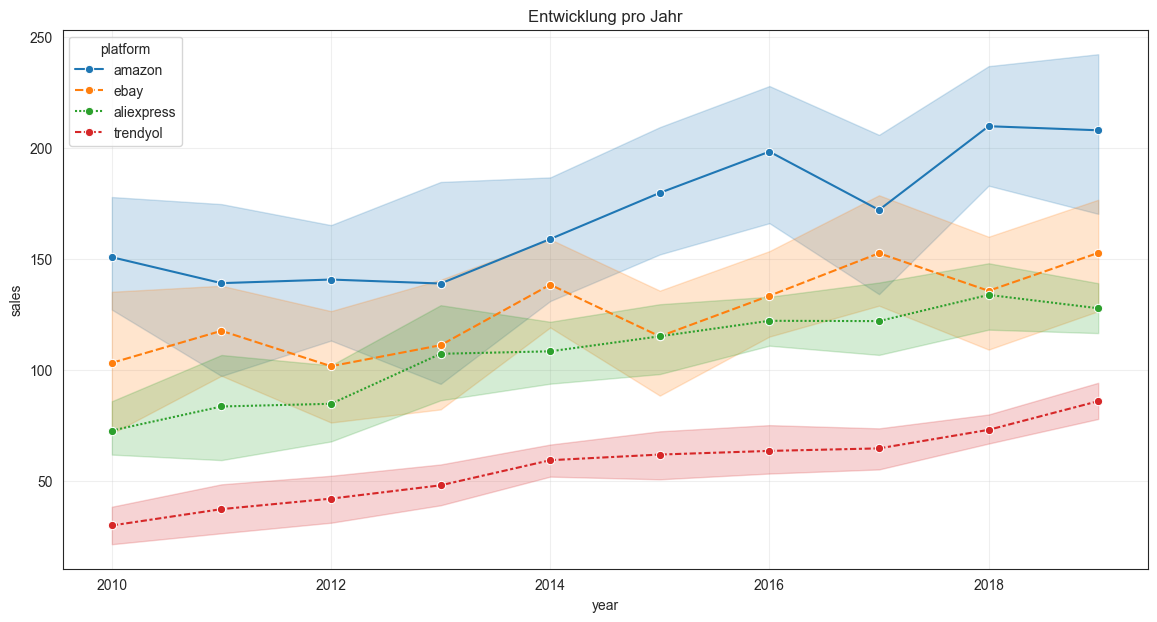

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vorbereitung: Monat und Jahr extrahieren
df_yr = df.with_columns([
    pl.col("datetime").dt.year().alias("year")
])

# Plot: Monatliche Saisonalität über die Jahre hinweg
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df_seasonal.to_pandas(), 
    x="year", 
    y="sales", 
    hue="platform", 
    style="platform",
    marker="o"
)

plt.title("Entwicklung pro Jahr")
plt.grid(True, alpha=0.3)
plt.show()

## Check auf den Einfluss von Feiertagen

In [31]:
import holidays
import pandas as pd

years = list(range(2010, 2021))

us_all = holidays.US(years=years)
tr_all = holidays.TR(years=years)
cn_all = holidays.CN(years=years)

In [60]:
df_us_hols = pl.DataFrame(
    [(datum, name) for datum, name in us_all.items()],
    schema=["datetime", "holiday_name_us"]
)
df_us_hols

C:\Users\maxkr\AppData\Local\Temp\ipykernel_24220\2166351818.py:1: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  df_us_hols = pl.DataFrame(


datetime,holiday_name_us
date,str
2016-01-01,"""New Year's Day"""
2016-05-30,"""Memorial Day"""
2016-07-04,"""Independence Day"""
2016-09-05,"""Labor Day"""
2016-11-24,"""Thanksgiving Day"""
…,…
2015-12-25,"""Christmas Day"""
2015-01-19,"""Martin Luther King Jr. Day"""
2015-02-16,"""Washington's Birthday"""


In [61]:
df_hols_monthly = (
    df_us_hols
    .with_columns(
        pl.col("datetime").dt.truncate("1mo").alias("year_month")
    )
    .group_by("year_month")
    .agg(
        pl.count("holiday_name_us").alias("holiday_count_us")
    )
)
df_hols_monthly

year_month,holiday_count_us
date,u32
2014-07-01,1
2014-02-01,1
2010-12-01,3
2020-07-01,2
2018-05-01,1
…,…
2020-05-01,1
2012-05-01,1
2018-11-01,3


In [66]:
df_amazon = df_amazon.with_columns(
    pl.col("datetime").dt.truncate("1mo").alias("year_month")
)

df_final = (
    df_amazon.join(df_hols_monthly, on="year_month", how="left")
    .with_columns(
        pl.col("holiday_count_us").fill_null(0)  # Monate ohne Feiertage auf 0 setzen
    )
)


df_final


datetime,amazon,year_month,holiday_count_us
date,f64,date,u32
2010-01-31,162.50523,2010-01-01,2
2010-02-28,131.234988,2010-02-01,1
2010-03-31,142.409296,2010-03-01,0
2010-04-30,265.024017,2010-04-01,0
2010-05-31,154.458817,2010-05-01,1
…,…,…,…
2019-08-31,156.385032,2019-08-01,0
2019-09-30,139.163315,2019-09-01,1
2019-10-31,64.840904,2019-10-01,1


C:\Users\maxkr\AppData\Local\Temp\ipykernel_24220\3455064355.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


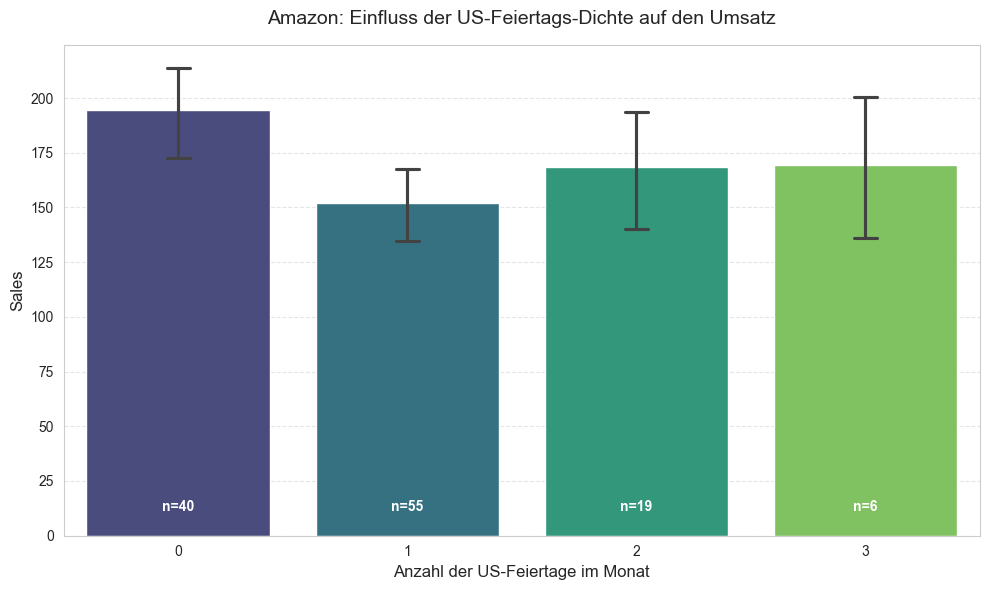

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=df_final.to_pandas(), 
    x="holiday_count_us", 
    y="amazon", 
    palette="viridis",
    capsize=.1
)

# Titel und Achsen
plt.title("Amazon: Einfluss der US-Feiertags-Dichte auf den Umsatz", fontsize=14, pad=15)
plt.ylabel("Sales", fontsize=12)
plt.xlabel("Anzahl der US-Feiertage im Monat", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

counts = df_final["holiday_count_us"].value_counts().sort("holiday_count_us")
for i, count in enumerate(counts["count"]):
    plt.text(i, plt.ylim()[1]*0.05, f'n={count}', ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

Die Annhame, das Feiertage und in den Monaten einen Einfluss auf den Verkauf haben kann verworfen werden. So zeigt der Plot bereits das Monate mit vielen Feiertagen nicht unbesondingt mehr Umsatz auf weisen. Nachdem der Ersteller des Datensatzes kontaktiert wurden, wurde diese Idee noch weiter verworfen. Das hat folgende Gründe: 

1. Es gibt keinen wirklichen geographischen Hintergrund
2. Die Plattform Spalten sind nur generische E-Commerce Kanäle
3. Die Daten wurden nicht auf Basis regionaler Muster erstellt